In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df =pd.read_csv('/House Price Prediction Dataset.csv')
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
(2000, 10)
Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [ ]:
df = df.select_dtypes(include=[np.number])
df=df.dropna()

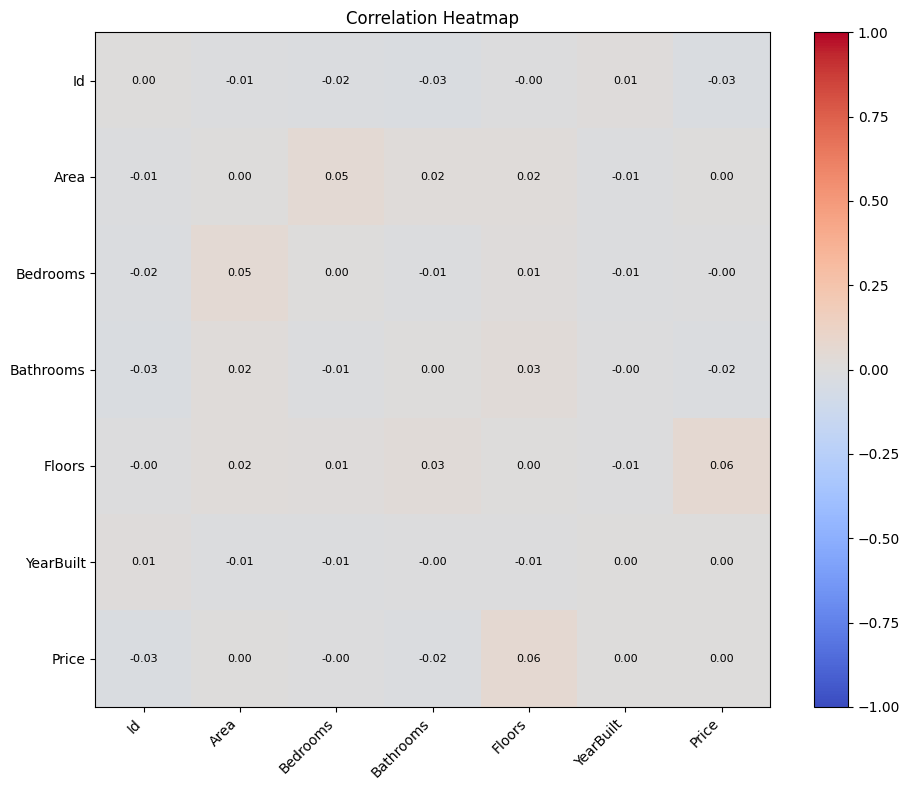

In [ ]:
#Correlation Heatmap Core
corr=df.corr()
np.fill_diagonal(corr.values, 0)
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns,rotation=45,ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
  for j in range(len(corr)):
   ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [ ]:
#Outlier Removal
def remove_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    mask=~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)
    return data[mask]

df_clean = remove_outliers_iqr(df)
print(f"Befor:{len(df)} rows → After: {len(df_clean)} rows")


Befor:2000 rows → After: 2000 rows


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Feautres and Target _
target_col='Price'
x=df_clean.drop(columns=[target_col]).values
y=df_clean[target_col].values


In [ ]:
#Feautres and Scaling
x_mean=x.mean(axis=0)
x_std=x.std(axis=0)
x_norm=(x-x_mean)/x_std

In [ ]:
x_b = np.c_[np.ones(x_norm.shape[0]), x_norm]


theta = np.linalg.pinv(x_b.T @ x_b) @ x_b.T @ y

print("Intercept:", theta[0])
print("Coefficients:", theta[1:])

Intercept: 537676.8550000002
Coefficients: [-7213.47446328   243.93819441 -1290.74313271 -5005.87331362
 15595.57495674  1484.13186655]


In [ ]:
#Prediction And Evaluations
y_pred=x_b @ theta
ss_res=np.sum((y-y_pred)**2)
ss_tot=np.sum((y-y.mean())**2)
r2=1-ss_res /ss_tot

rmse=np.sqrt(np.mean((y-y_pred)**2))

print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

R-squared: 0.0042
RMSE: 275785.41


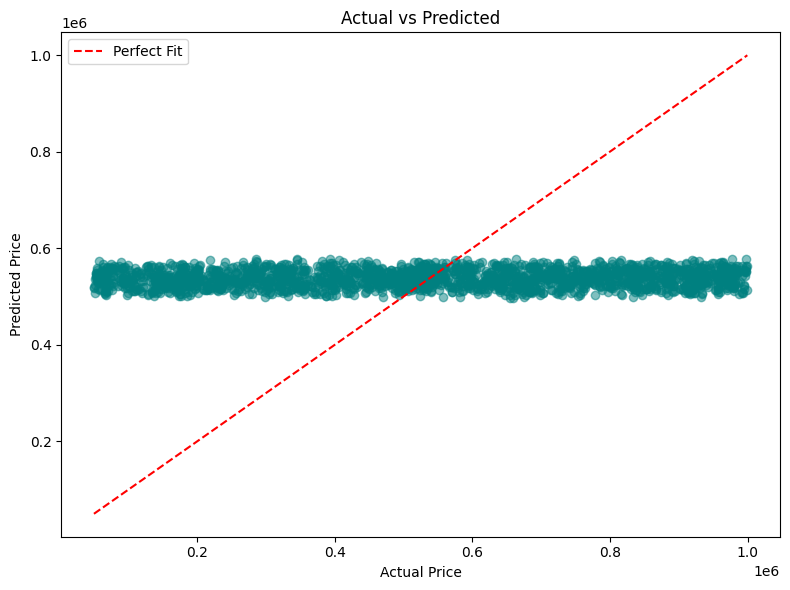

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y,y_pred,alpha=0.5, color='teal')
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--',label='Perfect Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Residuals Price
residuals=y-y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred,residuals,alpha=0.5,color='coral')
plt.axhline(0,color='Black',linestyle=':')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.tight_layout()
plt.show()

NameError: name 'y' is not defined